### Apply on data

In [1]:
import os
import sys

# sys.path.insert(1, os.path.expanduser("~/projects/phase_coupling_analysis/"))

In [2]:
import jax
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import gcmi_model_nd_cd
from frites.workflow import WfStats
from histogramMI import mutualInformationBin_jax
from hoi.core import get_mi
from mne.filter import filter_data
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from session import session_info
from tqdm import tqdm

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### Functions

In [4]:
def trial_to_string(trial_no, n_max):
    trial_no = str(trial_no)
    n = len(trial_no)
    return (n_max - n) * "0" + trial_no

In [5]:
def shuffle_along_axis(a, axis):
    """Shuffle data along specified axis."""
    idx = np.random.rand(*a.shape).argsort(axis=axis)
    return np.take_along_axis(a, idx, axis=axis)


def create_generalized_surrogates(X, n_boot=10000):
    """Create semi-generalized surrogate."""
    T, R, N = X.shape  # Extract dimensions

    # Trials onsets
    t_match_on = (data.attrs["t_match_on"] - data.attrs["t_cue_on"]) / data.fsample
    t_match_on = np.round(t_match_on, 1)

    X = X.values

    # Sample trials
    count = 0
    trials_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(T),
            size=2,
            replace=False,
        )
        trials_surr += [out]
        count = count + 1
    trials_surr = np.stack(trials_surr)

    # Sample channels
    count = 0
    channels_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(R),
            size=2,
            replace=False,
        )
        channels_surr += [out]
        count = count + 1
    channels_surr = np.stack(channels_surr)

    data_surr = []
    for c_i, c_j, trial_i, trial_j in np.concatenate(
        (channels_surr, trials_surr), axis=1
    ):
        x = X[trial_i, c_i]
        y = X[trial_j, c_j]  # [..., ::-1]
        data_surr += [np.stack((x, y))]

    # Get shortest onset time for each pair of sampled trials
    onsets = []
    for t1, t2 in trials_surr:
        onsets += [min(t_match_on[t1], t_match_on[t2])]
    onsets = np.stack(onsets)

    return np.stack(data_surr), onsets

In [6]:
sessions = np.loadtxt("sessions_betty.txt", dtype=str)

#### Load data

In [7]:
sessions = np.loadtxt("sessions_betty.txt", dtype=str)

print(sys.argv)
if len(sys.argv) > 3:
    index = int(sys.argv[3])
else:
    index = 0

# session = sessions[index]
session = "090615"

['/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/ipykernel_launcher.py', '-f', '/Users/vinicius/Library/Jupyter/runtime/kernel-1c43b7ec-9b87-4681-adbc-658da3f860d5.json']


In [8]:
root = f"/Users/vinicius/data/GrayLab/betty/{session}/session01/"

save_path = f"figures/data/coherence/{session}"

if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [9]:
trial_info = {}
scipy.io.loadmat(
    os.path.join(root, "trial_info.mat"), simplify_cells=True, mdict=trial_info
)
trial_info = trial_info["trial_info"]

In [10]:
recording_info = {}
scipy.io.loadmat(
    os.path.join(root, "recording_info.mat"), simplify_cells=True, mdict=recording_info
)
recording_info = recording_info["recording_info"]

In [11]:
task_trials = np.where(
    trial_info["behavioral_response"]
    * trial_info["stable_trials"]
    * trial_info["good_trials"]
    # * trial_info["rule"] == 1
)[0]

In [12]:
stim = []


for trial in task_trials:

    if trial_info["rule"][trial] == 1:
        stim.append(trial_info["match_image"][trial])
    else:
        stim.append(trial_info["match_location"][trial])

In [13]:
time_array = np.arange(-0.4, 1.7, 1 / recording_info["lfp_sampleingrate"])

In [14]:
n_trials, n_channels, n_times = (
    len(task_trials),
    recording_info["channel_count"],
    len(time_array),
)

In [15]:
data = np.empty((n_trials, n_channels, n_times))  # LFP data

# For each selected trial
i = 0
for trial in tqdm(task_trials):

    lfp_data = scipy.io.loadmat(
        os.path.join(root, f"betty{session}01.{trial_to_string(trial + 1, 4)}.mat")
    )["lfp_data"]

    # Beggining and ending time index for this t0
    indb = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.min()
    )
    inde = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.max()
    )
    # LFP data, dimension NtrialsxNchannelsxTime
    data[i, ...] = lfp_data[:, indb : inde + 1]

    i = i + 1

100%|████████████████████████████████| 993/993 [00:02<00:00, 469.73it/s]


#### Convert to xarray

In [16]:
data = xr.DataArray(
    data,
    dims=("trials", "roi", "times"),
    coords=(
        # trial_info["match_image"][task_trials],
        stim,
        recording_info["area"],
        time_array,
    ),
    attrs={
        "t_match_on": trial_info["match_on"],
        "t_cue_on": trial_info["sample_on"],
        "fsample": recording_info["lfp_sampleingrate"],
    },
)

(-0.5, 1.7, -4.561347220428129, 18.97876915494902)

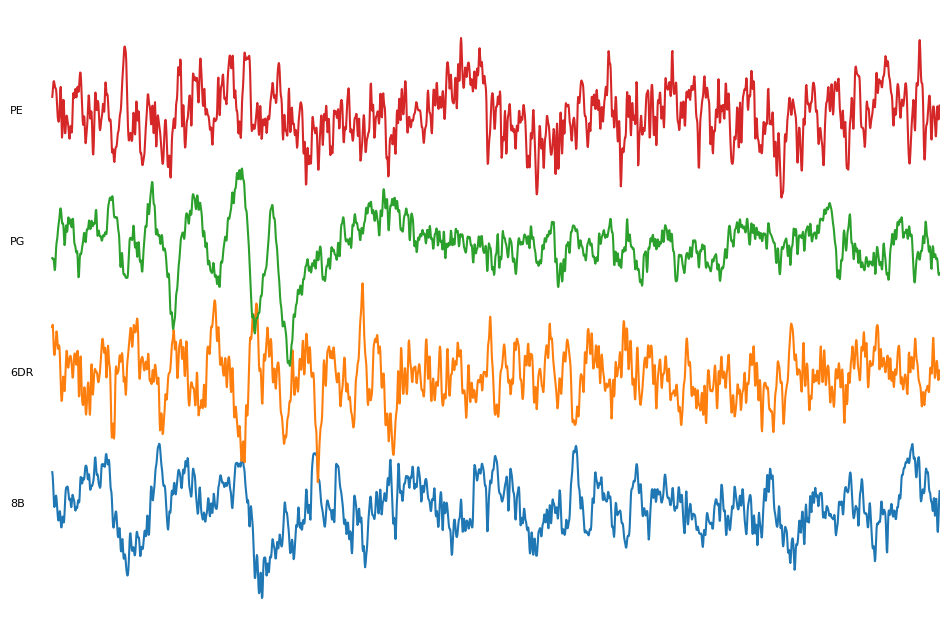

In [17]:
plt.figure(figsize=(12, 8))
zdata = (data - data.mean("times")) / data.std("times")


for i in range(data.sizes["roi"]):

    plt.plot(data.times, zdata[0, i] + (i * 5))
    plt.text(-0.5, (i * 5), zdata.roi.values[i])

plt.xlim(-0.5, 1.7)
plt.axis("off")

#### Surrogate coherence

In [18]:
from frites.utils import parallel_func


def return_coh():

    data_surr, _ = create_generalized_surrogates(data, data.sizes["trials"])

    freqs = np.linspace(0.1, 50, 50)

    W = tfr_array_multitaper(
        data_surr,
        recording_info["lfp_sampleingrate"],
        freqs,
        n_cycles=freqs / 2,
        time_bandwidth=8,
        decim=10,
        output="complex",
        verbose=False,
        n_jobs=1,
    )

    Sxy = (W[:, 0] * np.conj(W[:, 1])).mean(0)
    Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
    Syy = (W[:, 1] * np.conj(W[:, 1])).mean(0)

    return (np.abs(Sxy) ** 2 / (Sxx * Syy)).real


# define the function to compute in parallel
parallel, p_fun = parallel_func(return_coh, n_jobs=10, verbose=False, total=100)
# Compute the single trial coherence
out = parallel(p_fun() for t in range(100))

 70%|████████████████████▎        |  : 70/100 [02:08<00:57,    1.91s/it]/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|████████████████████████████|  : 100/100 [03:35<00:00,    2.15s/it]


[0.010658499248548295]


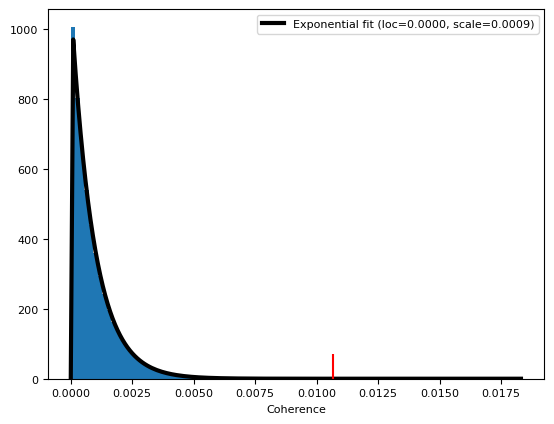

In [19]:
coh_surr_pooled = np.stack(out).flatten()

# Fit the exponential distribution
fit_loc, fit_scale = scipy.stats.expon.fit(coh_surr_pooled)

x = np.arange(0, coh_surr_pooled.max(), 0.0001)

# Calculate the exponential PDF with fit parameters
expon_pdf = scipy.stats.expon.pdf(x, loc=fit_loc, scale=fit_scale)

plt.hist(coh_surr_pooled, 100, density=True)

# Plot the Exponential distribution
plt.plot(
    x,
    expon_pdf,
    label=f"Exponential fit (loc={fit_loc:.4f}, scale={fit_scale:.4f})",
    color="k",
    lw=3,
)

# Calculate thresholds for extreme values
thr_coh = [
    scipy.stats.expon.ppf(1 - p, loc=fit_loc, scale=fit_scale) for p in [0.00001]
]

# Plot threshold lines
[plt.vlines(thr_coh[i], 0, 70, color="r") for i in range(len(thr_coh))]
print(thr_coh)
plt.xlabel("Coherence")
plt.legend()
plt.show()

#### Coherence

In [20]:
freqs = np.linspace(0.1, 30, 50)

W = tfr_array_multitaper(
    data,
    recording_info["lfp_sampleingrate"],
    freqs,
    n_cycles=freqs / 2,
    decim=20,
    time_bandwidth=5,
    output="complex",
    verbose=True,
)

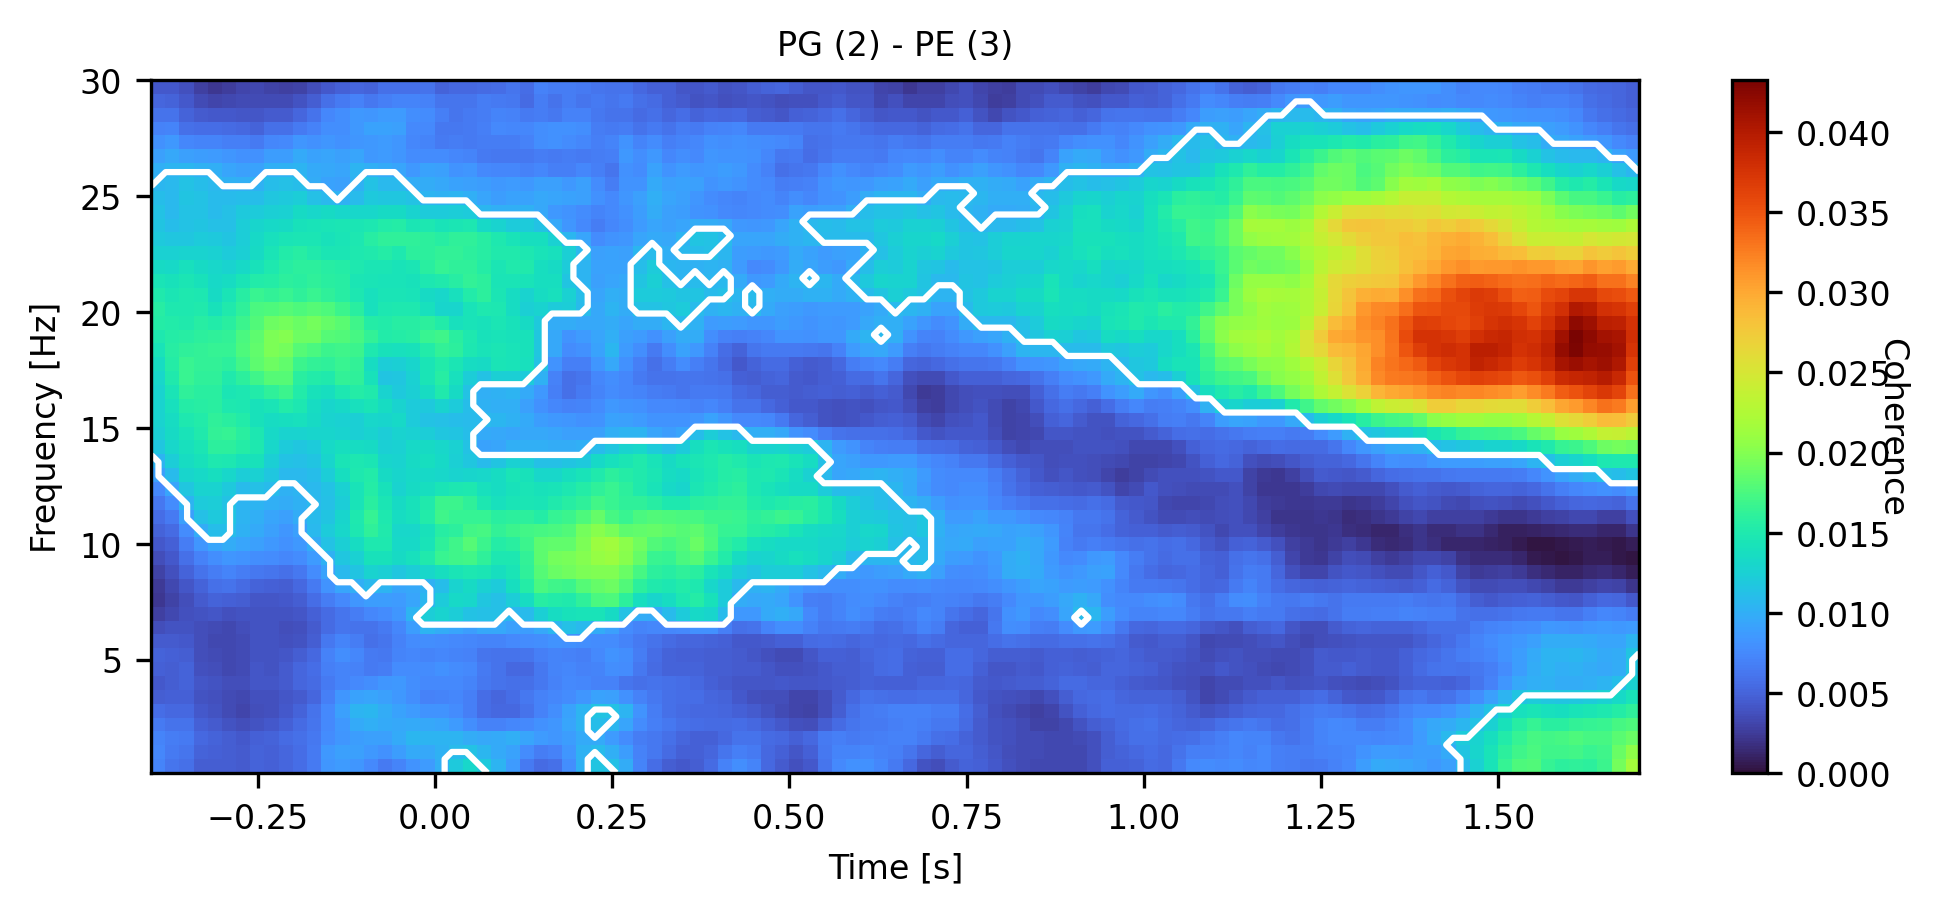

In [21]:
fig = plt.figure(num=1, clear=True, figsize=(8, 3), dpi=300)


for i in range(data.sizes["roi"]):
    for j in range(i + 1, data.sizes["roi"]):

        fig = plt.figure(num=1, clear=True)

        Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
        Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
        Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

        coh = np.abs(Sxy) ** 2 / (Sxx * Syy)

        plt.imshow(
            coh.real,
            aspect="auto",
            origin="lower",
            cmap="turbo",
            extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
            vmin=0,
            vmax=coh.real.max(),
        )
        cbar = plt.colorbar()

        cbar.set_label("Coherence", rotation=270)
        plt.xlabel("Time [s]")
        plt.ylabel("Frequency [Hz]")
        plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

        plt.contour(
            (coh.real > thr_coh[0]),
            levels=[0.5],
            colors="w",
            extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
        )

        plt.savefig(
            os.path.join(
                save_path,
                f"coherence_spectra_{data.roi.values[i]}_{i} - {data.roi.values[j]}_{j}.pdf",
            )
        )

#### Stimulus related coherence (SCR)

In [22]:
x_s, x_t = np.triu_indices(data.sizes["roi"], 1)

In [23]:
z = (W[:, x_s] * np.conj(W[:, x_t])).mean(2)


A = np.abs(z)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)
mv = np.stack((A, dphi))

I_S_R1 = gcmi_model_nd_cd(
    A[None], np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

I_S_R2 = gcmi_model_nd_cd(
    dphi[None], np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

I_S_R1_R2 = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

In [24]:
from joblib import Parallel, delayed


def compute_shuffle(mv):

    # compute MI
    return gcmi_model_nd_cd(
        mv, np.random.permutation(data.trials.values), mvaxis=0, traxis=1, gcrn=True
    )


# run in parallel
I_S_R1_R2_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(1_000))
)

100%|███████████████████████████████| 1000/1000 [18:18<00:00,  1.10s/it]


In [25]:
x = [np.asarray(I_S_R1_R2[i][None]) for i in range(len(x_s))]
y = [np.stack(I_S_R1_R2_shuffle)[:, i][:, None] for i in range(len(x_s))]

In [26]:
wf = WfStats()

p, t = wf.fit(
    x,
    y,
    inference="ffx",
    mcp="cluster",
)

p = p.squeeze()

p.min()

Definition of a non-parametric statistical workflow
    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.00893485233126961; tail=1)


0.001

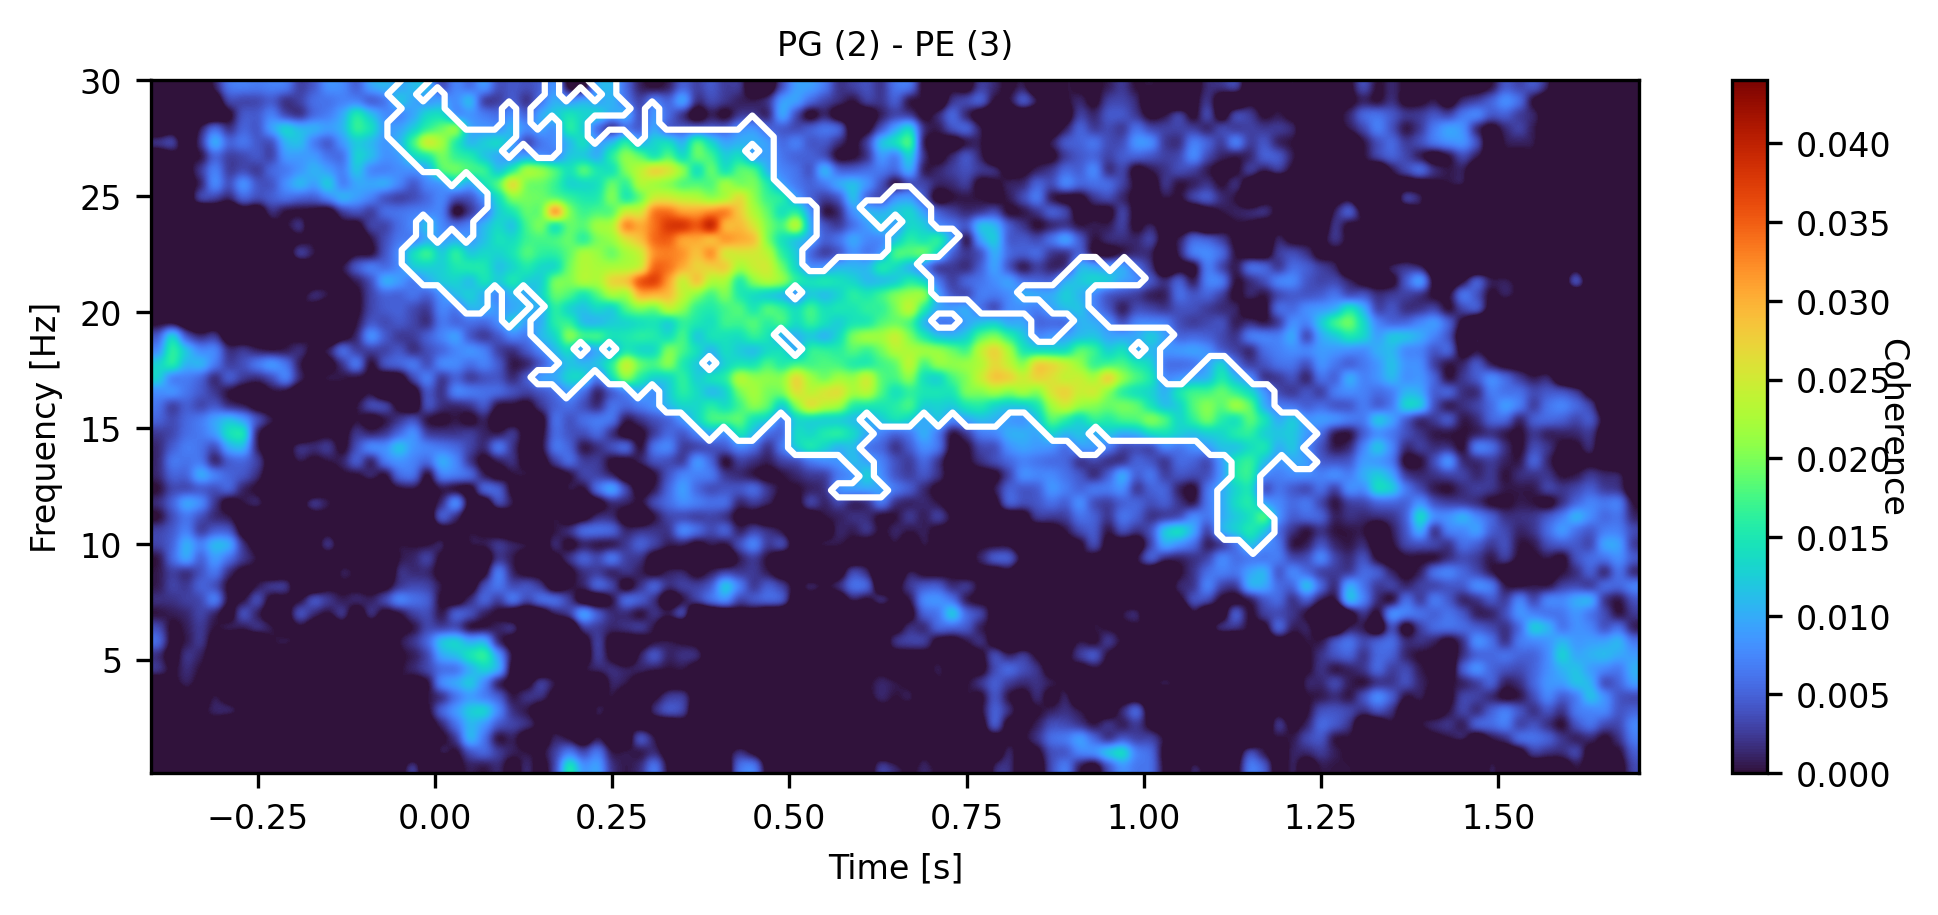

In [27]:
fig = plt.figure(num=1, clear=True, figsize=(8, 3), dpi=300)

pos = 0

for i, j in zip(x_s, x_t):

    fig = plt.figure(num=1, clear=True)

    plt.imshow(
        I_S_R1_R2[pos],
        aspect="auto",
        origin="lower",
        cmap="turbo",
        extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
        vmin=0,
        interpolation="gaussian",
        vmax=I_S_R1_R2[pos].max(),
    )
    cbar = plt.colorbar()

    plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

    cbar.set_label("Coherence", rotation=270)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")

    plt.contour(
        (p[..., pos] <= 0.05),
        levels=[0.5],
        colors="w",
        extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    )

    plt.savefig(
        os.path.join(
            save_path,
            f"total_MI_{data.roi.values[i]}_{i} - {data.roi.values[j]}_{j}.pdf",
        )
    )

    pos = pos + 1

In [28]:
red = np.minimum(I_S_R1, I_S_R2)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)

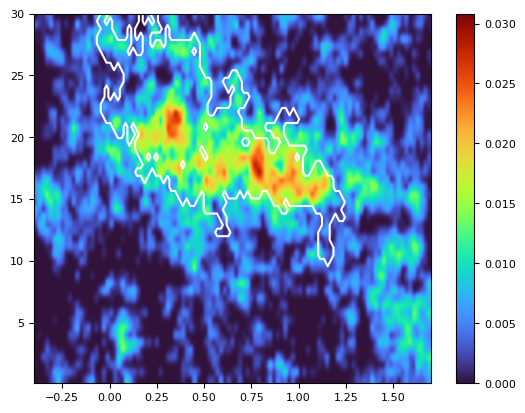

In [29]:
plt.imshow(
    I_S_R1[-1] - red[-1],
    aspect="auto",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    origin="lower",
    cmap="turbo",
    interpolation="gaussian",
)
plt.colorbar()

plt.contour(
    (p[..., -1] <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

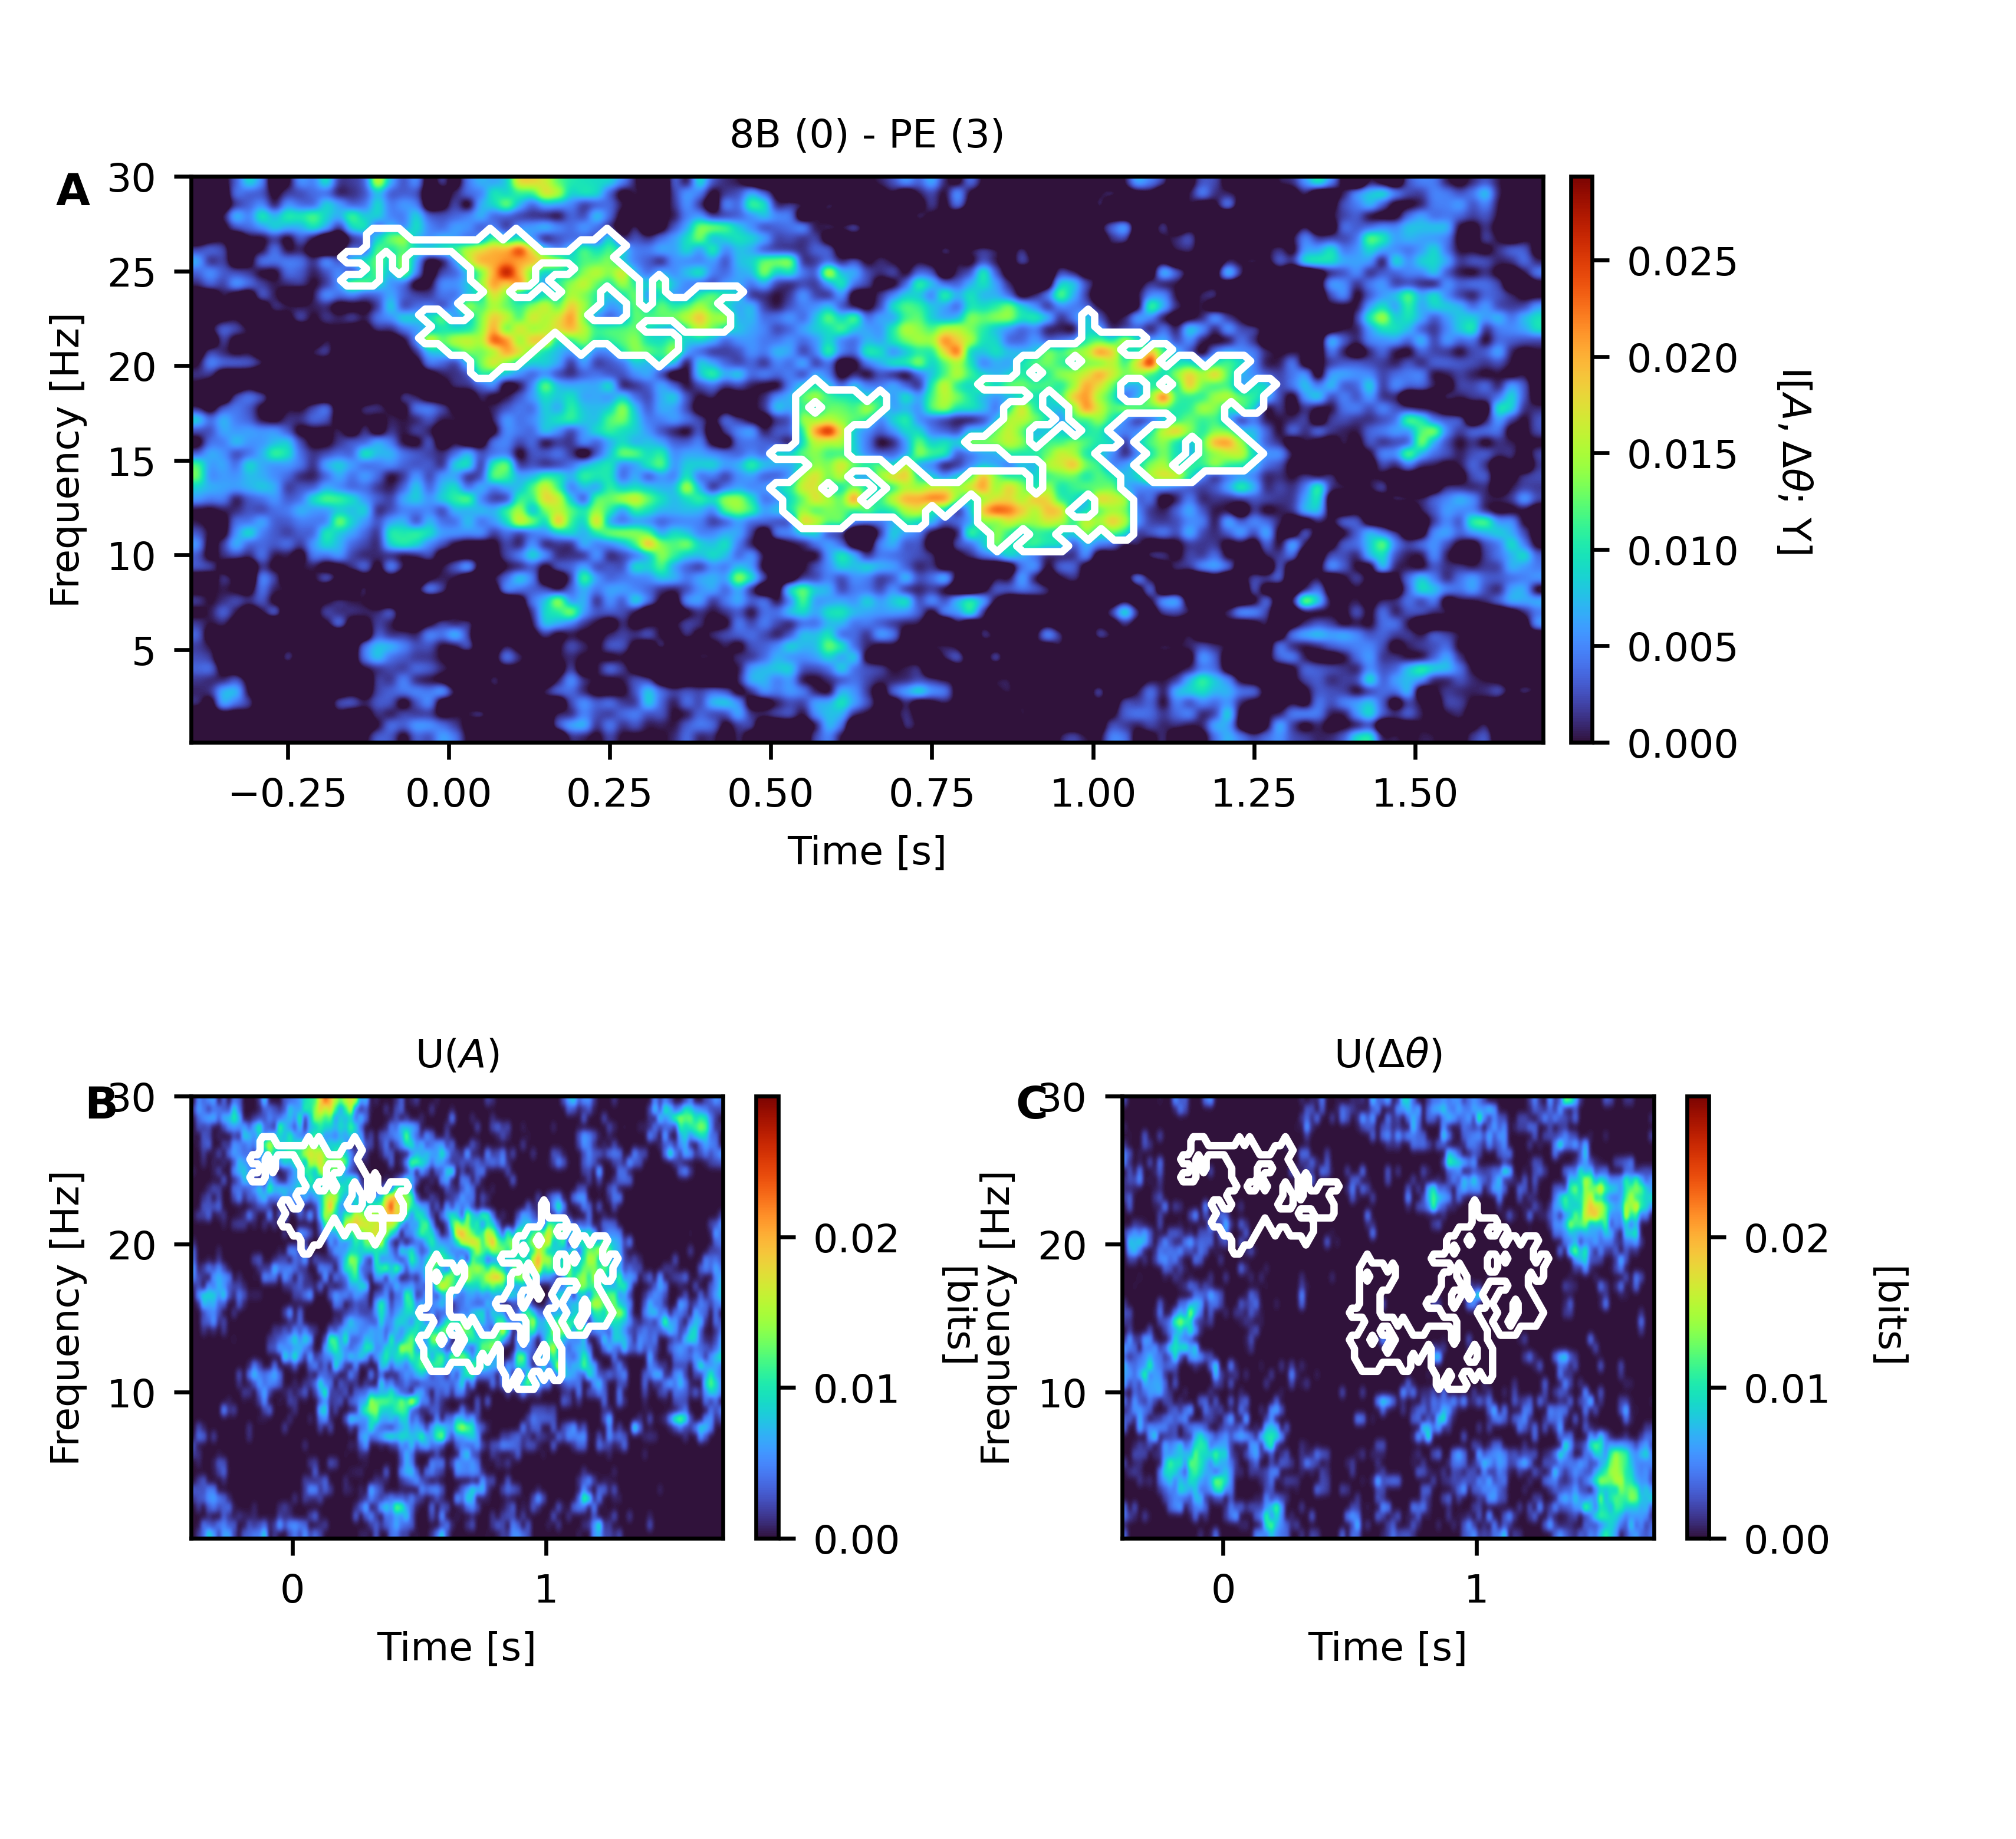

In [54]:
import plot
from PIL import Image

pos = 2

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.8,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.95, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2[pos],
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label(r"I[$A, \Delta\theta$; Y]", rotation=270, labelpad=15)

plt.contour(
    (p[..., pos].squeeze() <= 0.5),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(f"{data.roi.values[i]} ({i}) - {data.roi.values[j]} ({j})")

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

plt.sca(ax2)
plt.imshow(
    (I_S_R1[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p[..., pos].squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


plt.title(r"U($A$)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
cbar.set_label("[bits]", rotation=270, labelpad=15)

plt.sca(ax3)

plt.imshow(
    (I_S_R2[pos] - red[pos]),
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=I_S_R1_R2.max() / 1.5,
)
cbar = plt.colorbar()

plt.title(r"U($\Delta\theta$)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("[bits]", rotation=270, labelpad=15)
plt.contour(
    (p[..., pos].squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-.1] + [-0.2] * 2,
    ypos=[0.95] * 3,
)

plt.savefig("../Figures/Figure5.pdf")

In [55]:
i, j = 2, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh1 = np.abs(Sxy) ** 2 / (Sxx * Syy)

i, j = 0, 3

Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

coh2 = np.abs(Sxy) ** 2 / (Sxx * Syy)

In [56]:
z = (W[:, 0] * np.conj(W[:, 1])).mean(1)

dphi1 = np.abs(z)[None]  # np.stack((z.real, z.imag))
# dphi1 = np.abs((dphi1 + np.pi) % (2 * np.pi) - np.pi)


z = (W[:, 2] * np.conj(W[:, 3])).mean(1)
dphi2 = np.abs(z)[None]  # np.stack((z.real, z.imag))

mv = np.concatenate((dphi1, dphi2))

# labels = np.tile(np.expand_dims(data.trials.values, (1, 2)), (W.shape[3], W.shape[4]))

I_S_R1_hoi = gcmi_model_nd_cd(
    dphi1, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

I_S_R2_hoi = gcmi_model_nd_cd(
    dphi2, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

I_S_R1_R2_hoi = gcmi_model_nd_cd(
    mv, np.asarray(data.trials.values), mvaxis=0, traxis=1, gcrn=True
)

In [57]:
# run in parallel
I_S_R1_R2_hoi_shuffle = Parallel(n_jobs=5)(
    delayed(compute_shuffle)(mv) for n in tqdm(range(2_00))
)

100%|█████████████████████████████████| 200/200 [00:37<00:00,  5.26it/s]


In [58]:
p_hoi, t = wf.fit(
    [np.asarray(I_S_R1_R2_hoi[None])],
    [np.stack(I_S_R1_R2_hoi_shuffle)[:, None]],
    inference="ffx",
    mcp="cluster",
)

p_hoi = p_hoi.squeeze()

p_hoi.min()

    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.009174496005645532; tail=1)


0.005

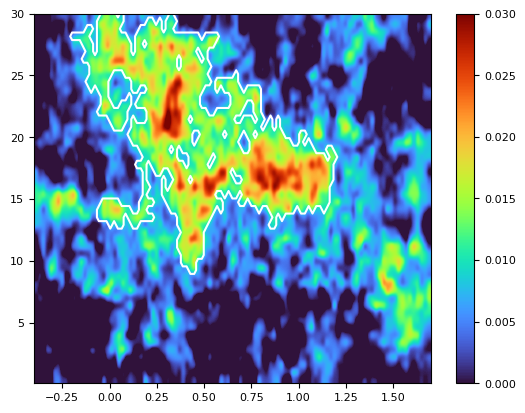

In [61]:
plt.imshow(
    I_S_R1_R2_hoi,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    vmin=0,
    vmax=0.03,
    interpolation="gaussian",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

plt.colorbar()

plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

In [62]:
red = np.minimum(I_S_R1_hoi, I_S_R2_hoi)
syn = I_S_R1_R2_hoi - np.maximum(I_S_R2_hoi, I_S_R1_hoi)

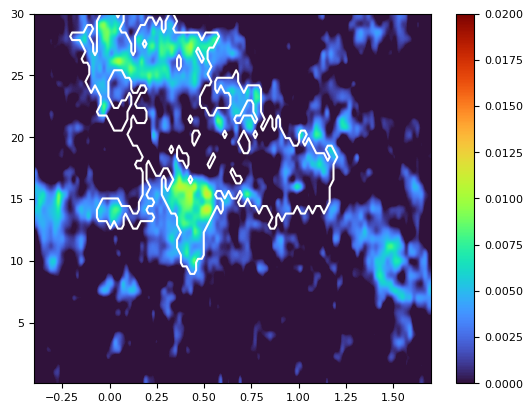

In [64]:
plt.imshow(
    red,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    vmin=0,
    vmax=0.02,
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    interpolation="gaussian",
)
plt.colorbar()

plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

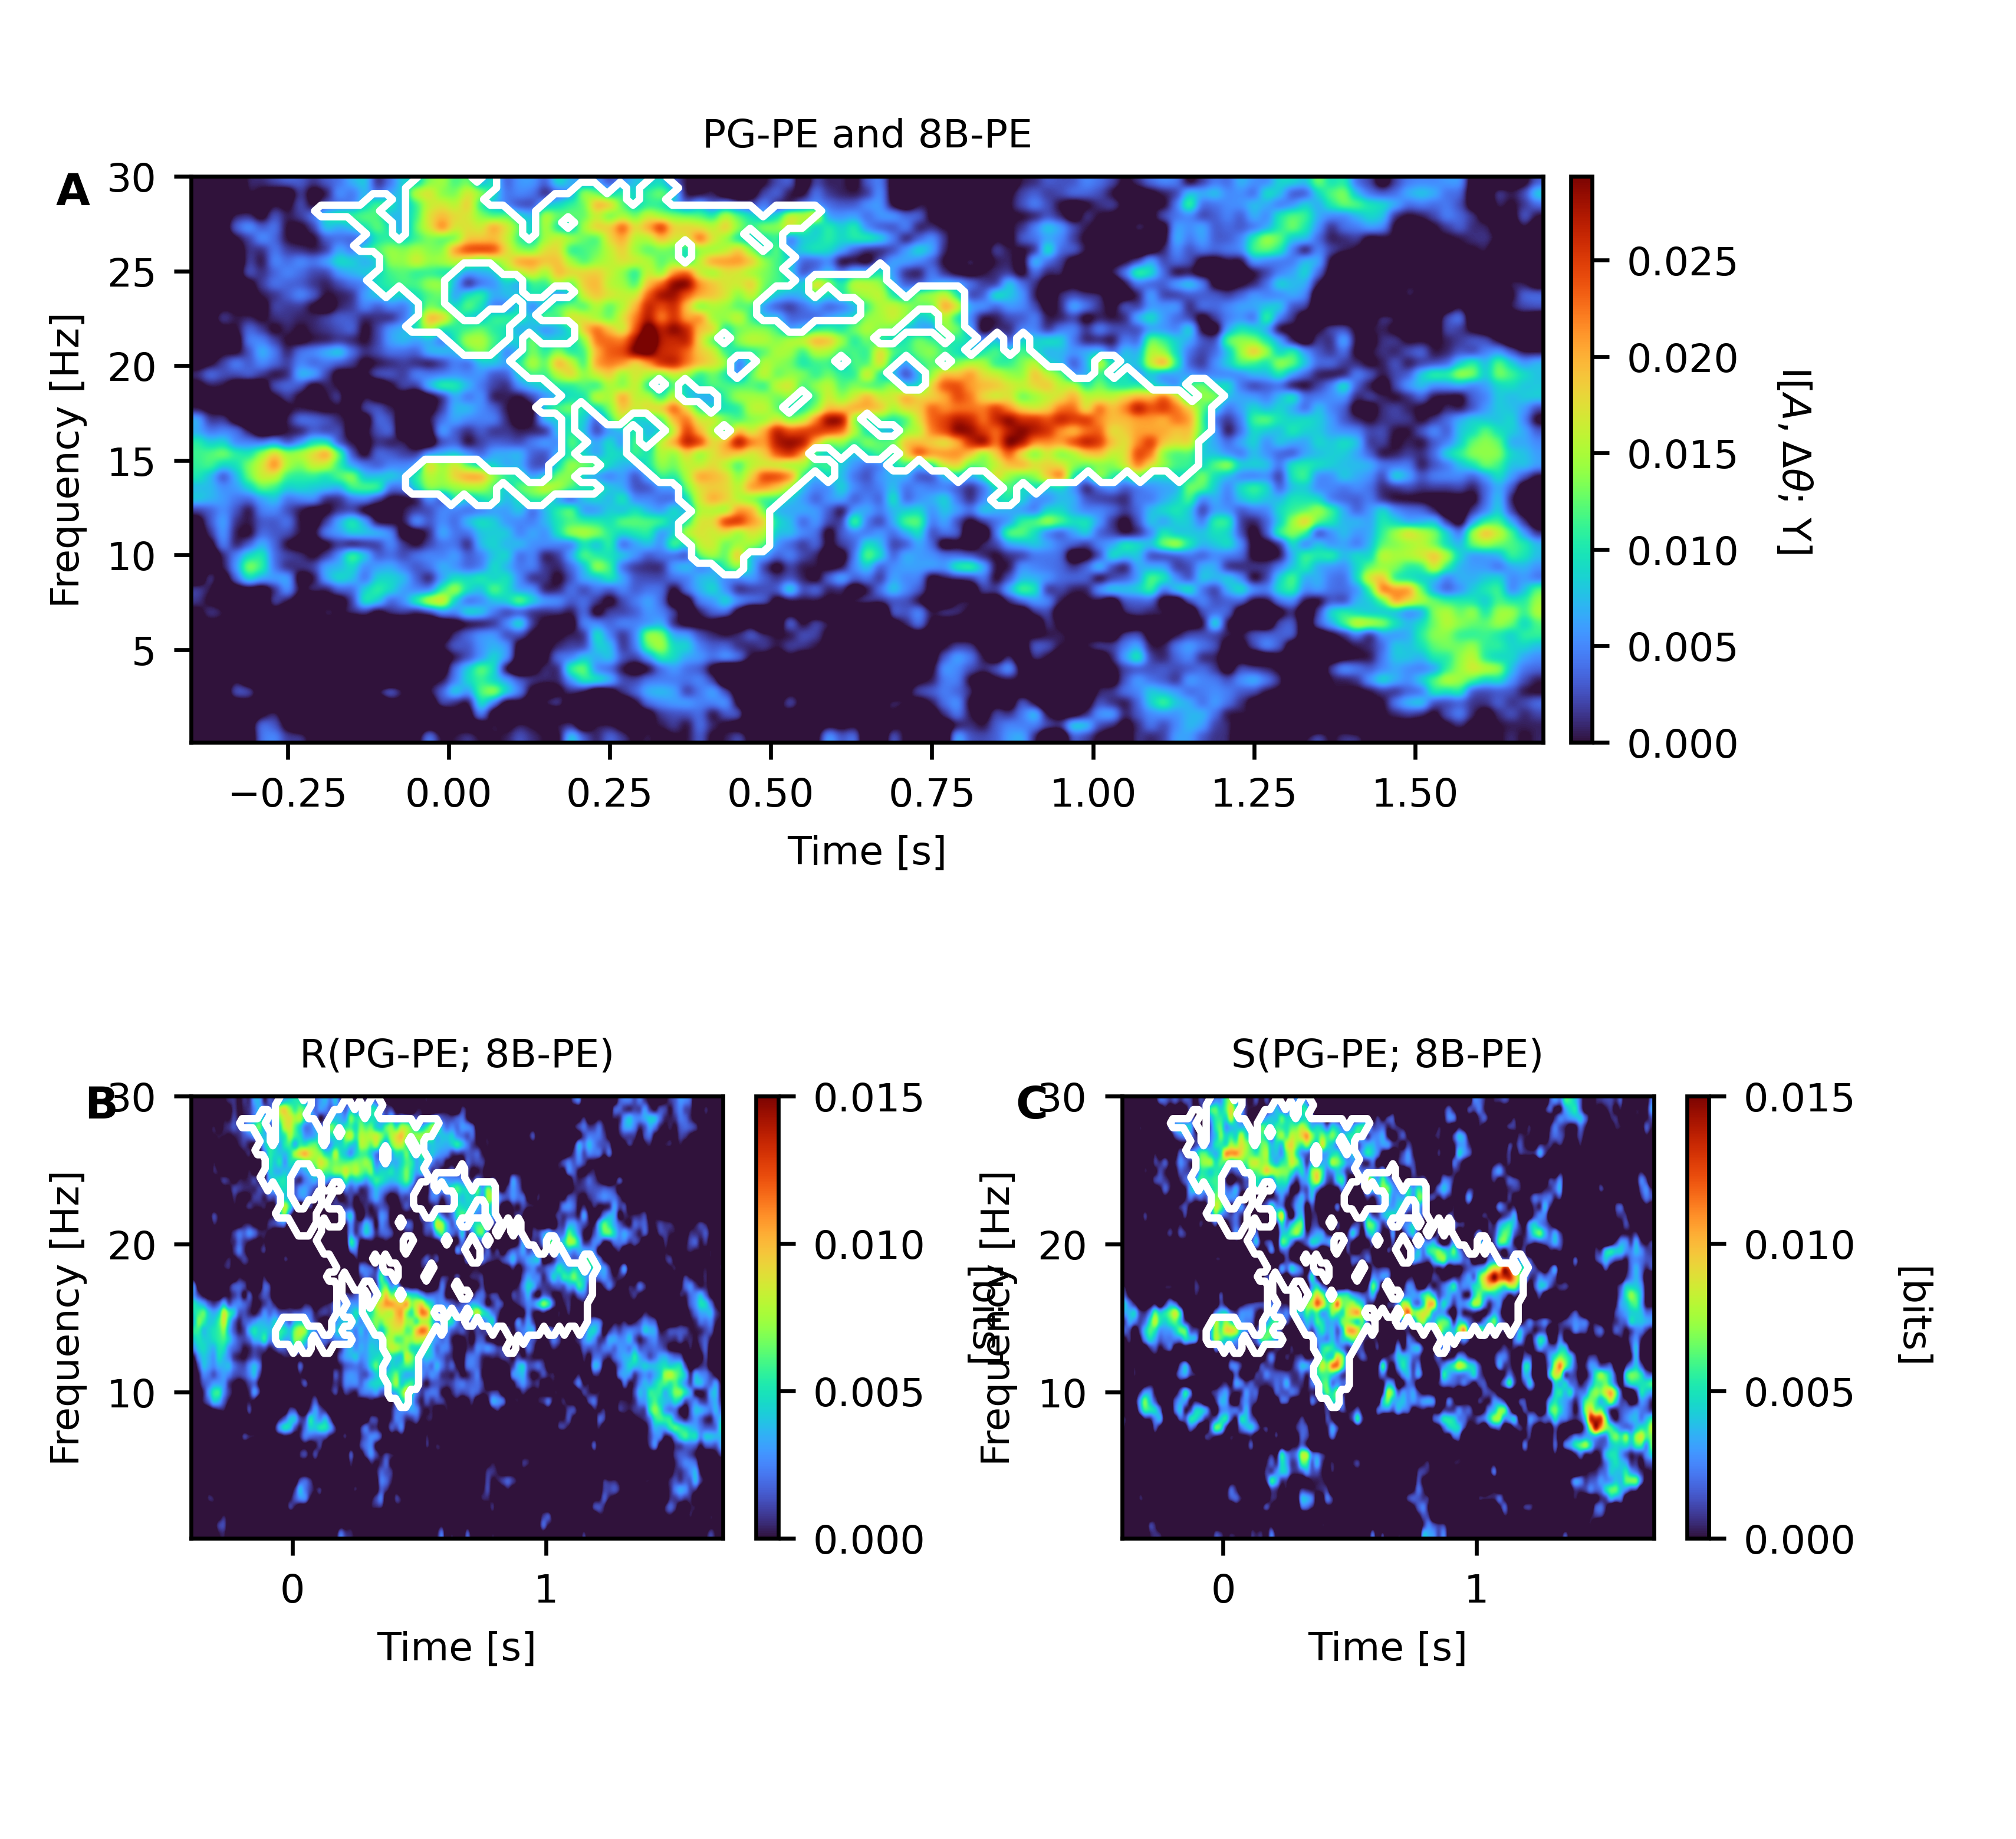

In [72]:
import plot
from PIL import Image

fig = plt.figure(figsize=(5.5, 5), dpi=600)

gs1 = fig.add_gridspec(
    nrows=1,
    ncols=2,
    left=0.08,
    right=0.8,
    bottom=0.6,
    top=0.92,
    wspace=0.04,
    width_ratios=[0.95, 0.015],
)
gs2 = fig.add_gridspec(
    nrows=1, ncols=2, left=0.08, right=0.90, bottom=0.15, top=0.4, wspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])
ax1cb = plt.subplot(gs1[1])

# Panel B-D
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])


plt.sca(ax1)
im = plt.imshow(
    I_S_R1_R2_hoi,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=I_S_R1_R2.max() / 1.5,
    interpolation="gaussian",
)
# assign colorbar to the correct axis
cbar = plt.colorbar(im, cax=ax1cb)
cbar.set_label(r"I[$A, \Delta\theta$; Y]", rotation=270, labelpad=15)

plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)

i, j = x_s[pos], x_t[pos]

plt.title(f"PG-PE and 8B-PE")

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

plt.sca(ax2)
plt.imshow(
    red,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    vmax=.015,
    interpolation="gaussian",
)
cbar = plt.colorbar()
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


plt.title(r"R(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
cbar.set_label("[bits]", rotation=270, labelpad=15)

plt.sca(ax3)

plt.imshow(
    syn,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
    vmin=0,
    interpolation="gaussian",
    vmax=.015,
)
cbar = plt.colorbar()

plt.title(r"S(PG-PE; 8B-PE)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

cbar.set_label("[bits]", rotation=270, labelpad=15)
plt.contour(
    (p_hoi.squeeze() <= 0.05),
    levels=[0.5],
    colors="w",
    extent=[data.times.min(), data.times.max(), freqs[0], freqs[-1]],
)


bg = plot.Background(visible=False)

plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3],
    fontsize=MEDIUM_SIZE,
    xpos=[-.1] + [-0.2] * 2,
    ypos=[0.95] * 3,
)

plt.savefig("../Figures/Figure6.pdf")